# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [2]:
# alternative functions (more variables)

dtypes = {'drifter_id':str}
def prepared_drifters(drifter_key) : 
    dfr = pd.read_csv(DRIFTER[drifter_key], parse_dates=['datetime'], dtype=dtypes).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['core']= -dfr.f * dfr.velocity_north
    dfr['corn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr
    
def prepared_alti(alti_key, ggd_var=['duacs_ssha_karin_2_filtered','duacs_ssha_karin_2_calibrated','cvl_mean_dynamic_topography_cnes_cls_22','cvl_ocean_tide_fes_2022']) :
    dfs = pd.read_csv(ALTI[alti_key]).set_index('row_number')
    dfs['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)
    dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
    dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs
    dfs = dfs[['ggde_'+v for v in ggd_var]+['ggdn_'+v for v in ggd_var]+['ggde_fromduacsv', 'ggdn_fromduacsv']]
    dfs['ggde_etaf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etaf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggde_etac'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etac'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtc'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtc'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    return dfs#.rename(columns ={v : v+'_' +alti_key for v in dfs})
    
def prepared_wd(wd_key): 
    dfw = pd.read_csv(WD[wd_key]).set_index('row_number')
    #dfw = dfw[[v for v in dfw if ('wde' in v or 'wdn' in v)]]
    return dfw.drop(columns = ['longitude', 'latitude'])#.rename(columns ={v : v+'_' +wd_key for v in dfw})



In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])


nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [4]:
dfr = prepared_drifters('nofilter') 
dfr['inertial_U'] = np.sqrt(dfr.inertial_velocity_east**2 + dfr.inertial_velocity_north**2)
dfr['inertial_A'] = np.sqrt(dfr.inertial_acceleration_east**2 + dfr.inertial_acceleration_north**2)
dfr['other_U'] = np.sqrt(dfr.other_velocity_east**2 + dfr.other_velocity_north**2)
dfr['diurnal_U'] = np.sqrt(dfr.diurnal_velocity_east**2 + dfr.diurnal_velocity_north**2)
dfr['semidiurnal_U'] = np.sqrt(dfr.semidiurnal_velocity_east**2 + dfr.semidiurnal_velocity_north**2)

In [5]:
dfs = DSS.to_dataframe().reset_index().set_index('row_number')
dfs

,id_comb,sume,acce,exce_acc,core,exce_cor,ggde,exce_ggd,wde,exce_wd,...,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi
row_number,,,,,,,,,,,,,,,,,,,,,
143,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000011,-0.000008,-0.000003,0.000012,-0.000023,-4.589065e-07,-0.000010,-0.000015,3.900978e-06,...,2023-04-01 11:50:00,5.537802,42.311468,3,0 days 11:52:32.696536,478,0-4351296,CARTHE,0,0.247750
144,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000011,-0.000009,-0.000002,0.000012,-0.000023,-6.610522e-07,-0.000010,-0.000014,2.857934e-06,...,2023-04-01 12:00:00,5.538871,42.310796,3,0 days 11:42:32.696536,478,0-4351296,CARTHE,0,0.247761
145,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000012,-0.000009,-0.000003,0.000012,-0.000024,-8.584202e-07,-0.000011,-0.000014,1.885442e-06,...,2023-04-01 12:10:00,5.539902,42.310135,3,0 days 11:32:32.696536,478,0-4351296,CARTHE,0,0.247771
146,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000013,-0.000010,-0.000003,0.000012,-0.000024,-1.233250e-06,-0.000011,-0.000014,8.161823e-07,...,2023-04-01 12:20:00,5.540894,42.309485,3,0 days 11:22:32.696536,478,0-4351296,CARTHE,0,0.247797
147,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000013,-0.000010,-0.000003,0.000011,-0.000025,-1.403116e-06,-0.000012,-0.000013,4.513496e-08,...,2023-04-01 12:30:00,5.541843,42.308849,3,0 days 11:12:32.696536,478,0-4351296,CARTHE,0,0.247804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404014,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000015,-0.000010,-0.000005,0.000015,-0.000030,-1.860577e-05,0.000004,-0.000002,-1.264567e-05,...,2023-07-10 06:10:00,2.018496,41.064212,16,0 days 11:13:38.131544384,577,295,HEREON,0,2.910344
404015,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000015,-0.000010,-0.000006,0.000016,-0.000031,-1.907019e-05,0.000004,-0.000002,-1.312333e-05,...,2023-07-10 06:20:00,2.016917,41.063333,16,0 days 11:23:38.131544384,577,295,HEREON,0,2.910313
404016,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000016,-0.000009,-0.000006,0.000016,-0.000031,-1.934054e-05,0.000004,-0.000002,-1.331414e-05,...,2023-07-10 06:30:00,2.015297,41.062453,16,0 days 11:33:38.131544384,577,295,HEREON,0,2.910291


In [ ]:
#.groupby(groupby, observed=False).mean()

In [67]:
def assign_attrs(ds, dirname=('e', 'n')) :
    for dir_ in dirname :
        if dir_ == 'e': Dir = 'Zonal'
        if dir_ == 'n': Dir = 'Meridional'
        if dir_ == 'x': Dir = 'Cross-track'
        if dir_ == 'n': Dir = 'Along-track'
        ds['ACC'+dir_] = ds['ACC'+dir_].assign_attrs({'long_name':Dir + ' Lagrangian acceleration MS'})
        ds['COR'+dir_] = ds['COR'+dir_].assign_attrs({'long_name':Dir + ' Coriolis acceleration MS'})
        ds['GGD'+dir_] = ds['GGD'+dir_].assign_attrs({'long_name':Dir + ' Pressure gradient term MS'})
        ds['WD'+dir_] = ds['WD'+dir_].assign_attrs({'long_name':Dir + ' Wind term MS'})
        
        
        ds['sigma'+dir_] = ds['sigma'+dir_].assign_attrs({'long_name':Dir+r' $\Sigma$'})
        ds['S'+dir_] = ds['S'+dir_].assign_attrs({'long_name':Dir+r' Residual'})
        
        ds['B'+dir_+'_acc'] = ds['B'+dir_+'_acc'].assign_attrs({'long_name':Dir+r' Lagrangian acceleration balanced signal contribution'})
        ds['B'+dir_+'_cor'] = ds['B'+dir_+'_cor'].assign_attrs({'long_name':Dir+r' Coriolis acceleration balanced signal contribution'})
        ds['B'+dir_+'_ggd'] = ds['B'+dir_+'_ggd'].assign_attrs({'long_name':Dir+r' Pressure gradient term balanced signal contribution'})
        ds['B'+dir_+'_wd'] = ds['B'+dir_+'_wd'].assign_attrs({'long_name':Dir+r' Wind term balanced signal contribution'})
        
        ds['E'+dir_+'_acc'] = ds['E'+dir_+'_acc'].assign_attrs({'long_name':Dir+r' Lagrangian acceleration residual contribution'})
        ds['E'+dir_+'_cor'] = ds['E'+dir_+'_cor'].assign_attrs({'long_name':Dir+r' Coriolis acceleration residual contribution'})
        ds['E'+dir_+'_ggd'] = ds['E'+dir_+'_ggd'].assign_attrs({'long_name':Dir+r' Pressure gradient term residual contribution'})
        ds['E'+dir_+'_wd'] = ds['E'+dir_+'_wd'].assign_attrs({'long_name':Dir+r' Wind term residual contribution'})
        
        
        ds['X'+dir_+'_acc_cor'] = ds['X'+dir_+'_acc_cor'].assign_attrs({'long_name':Dir+r' Inertial balance contribution'})
        ds['X'+dir_+'_acc_ggd'] = ds['X'+dir_+'_acc_ggd'].assign_attrs({'long_name':Dir+r' Cyclostrophique contribution'})
        ds['X'+dir_+'_acc_wd'] = ds['X'+dir_+'_acc_wd'].assign_attrs({'long_name':Dir+r' Lagrangian - wind contribution'})
        ds['X'+dir_+'_cor_ggd'] = ds['X'+dir_+'_cor_ggd'].assign_attrs({'long_name':Dir+r' Geostrophic contribution'})
        ds['X'+dir_+'_cor_wd'] = ds['X'+dir_+'_cor_wd'].assign_attrs({'long_name':Dir+r' Coriolis - wind contribution'})
        ds['X'+dir_+'_ggd_wd'] = ds['X'+dir_+'_ggd_wd'].assign_attrs({'long_name':Dir+r' Pressure gradient - wind contribution'})
    return ds


def compute_mean_square_groupby(df, groupby = 'time_to_swot_1h', dir_ = ('e', 'n'), bootstrap = True):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']

    #df = df.set_index(groupby)
    dff = (df[[v+dir_[1] for v in var] + [v+dir_[0] for v in var]]**2).rename(columns = {var[i]+dir_[1] : VAR[i]+dir_[1] for i in range(5)}).rename(columns = {var[i]+dir_[0] : VAR[i]+dir_[0] for i in range(5)})/U2
    dff = pd.concat([dff, df[groupby]], axis=1)
    
    nb_coloc = df.groupby(groupby, observed=False)['acc'+dir_[0]].count()

    #Balanced and error
    for direction in [dir_[0], dir_[1]]:
        dff['sigma'+direction] = dff['ACC'+direction] + dff['COR'+direction] + dff['GGD'+direction] + dff['WD'+direction]
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dff['B'+direction+'_'+v] = -((df[v+direction]*df['exc'+direction+'_'+v]))/U2
                dff['E'+direction+'_'+v] = ((df[v+direction]*df['sum'+direction]))/U2
    #pairs contributions
    for v in [v for v in df if 'prod' in v]:
        dff[v.replace('prod', 'X')]=-2*df[v]/U2

    # bootstrap errors
    def mean_df(df):
        return df.mean()
    from scipy.stats import bootstrap
    def compute_bootstrap_error(dff):
        # print(len(dff))
        if len(dff) < 3:
            return np.nan
        else:
            data = (dff,)  # samples must be in a sequence
            return bootstrap(data, statistic=mean_df).standard_error
            
    vars_errors = []
    for d in dir_:
        vars_errors += ["B" + d + '_' + v for v in var[:-1]]+ ["E" + d + '_' + v for v in var[:-1]] + [ v + d for v in VAR] + ['sigma'+d]+[v for v in dff.columns if 'X'+d+'_' in v]

    if bootstrap :
        import dask.dataframe as dd
        dfd = dd.from_pandas(dff)
        DF = []
        for v in vars_errors:
            DF.append(
                dfd.reset_index()[vars_errors + [groupby]]
                .groupby(groupby, observed=False)[v]
                .apply(compute_bootstrap_error)
                .compute()
            )
            print(v)
        booterrors = pd.concat(DF, axis=1)
        booterrors = booterrors.rename(columns={v: "ber__" + v for v in booterrors.columns})

    

    dff = dff.set_index(groupby)[vars_errors].groupby(groupby, observed=False).mean()
    dff['nb_coloc']= nb_coloc
    
    if bootstrap:
        dff = pd.concat([dff, booterrors], axis=1)
        
    dss = dff.to_xarray()
    dss = assign_attrs(dss, dir_)

    return dss

In [68]:
key_bins = 'inertial_U'
df = pd.concat([dfs, dfr[key_bins]], axis=1).dropna()
quantile = np.array([0] + [df[key_bins].quantile(i) for i in np.linspace(1e-3, 1-1e-3, 30)]) # 15 = 10 000 par cut
df[key_bins + '_cut']= pd.cut(df[key_bins], quantile, labels=(quantile[1:] + quantile[:-1])/2)

ds = compute_mean_square_groupby(df, groupby = key_bins + '_cut')



/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11680/1159289109.py:80: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Be_acc


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11680/1159289109.py:80: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Be_cor


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11680/1159289109.py:80: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


...

Xn_cor_ggd


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11680/1159289109.py:80: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Xn_cor_wd


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11680/1159289109.py:80: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Xn_ggd_wd


In [71]:
ds[0].to_netcdf(os.path.join(zarr_dir, 'binned_diag', key_bins + '.png'))

In [87]:
ds

<xarray.Dataset> Size: 20kB
Dimensions:          (inertial_U_cut: 30)
Coordinates:
  * inertial_U_cut   (inertial_U_cut) float64 240B 0.002327 0.01486 ... 0.4064
Data variables: (12/81)
    Be_acc           (inertial_U_cut) float64 240B 0.4489 0.4396 ... 4.09 7.626
    Be_cor           (inertial_U_cut) float64 240B 1.23 1.983 ... 5.499 10.07
    Be_ggd           (inertial_U_cut) float64 240B 0.7879 0.9162 ... 0.107
    Be_wd            (inertial_U_cut) float64 240B 0.5995 0.5063 ... 0.5155
    Ee_acc           (inertial_U_cut) float64 240B 0.4278 0.5194 ... 0.5471
    Ee_cor           (inertial_U_cut) float64 240B 0.9497 0.6237 ... 1.592
    ...               ...
    ber__Xn_acc_cor  (inertial_U_cut) float64 240B 0.2861 0.05271 ... 0.25
    ber__Xn_acc_ggd  (inertial_U_cut) float64 240B 0.2242 0.04233 ... 0.07262
    ber__Xn_acc_wd   (inertial_U_cut) float64 240B 0.06414 0.005942 ... 0.01757
    ber__Xn_cor_ggd  (inertial_U_cut) float64 240B 0.6267 0.09145 ... 0.06961
    ber__Xn_cor_wd   (inertial_U_cut) float64 240B 0.08951 0.01144 ... 0.01831
    ber__Xn_ggd_wd   (inertial_U_cut) float64 240B 0.05359 0.007781 ... 0.004181

In [86]:
list(ds.keys())

['Be_acc',
 'Be_cor',
 'Be_ggd',
 'Be_wd',
 'Ee_acc',
 'Ee_cor',
 'Ee_ggd',
 'Ee_wd',
 'ACCe',
 'CORe',
 'GGDe',
 'WDe',
 'Se',
 'sigmae',
 'Xe_acc_cor',
 'Xe_acc_ggd',
 'Xe_acc_wd',
 'Xe_cor_ggd',
 'Xe_cor_wd',
 'Xe_ggd_wd',
 'Bn_acc',
 'Bn_cor',
 'Bn_ggd',
 'Bn_wd',
 'En_acc',
 'En_cor',
 'En_ggd',
 'En_wd',
 'ACCn',
 'CORn',
 'GGDn',
 'WDn',
 'Sn',
 'sigman',
 'Xn_acc_cor',
 'Xn_acc_ggd',
 'Xn_acc_wd',
 'Xn_cor_ggd',
 'Xn_cor_wd',
 'Xn_ggd_wd',
 'nb_coloc',
 'ber__Be_acc',
 'ber__Be_cor',
 'ber__Be_ggd',
 'ber__Be_wd',
 'ber__Ee_acc',
 'ber__Ee_cor',
 'ber__Ee_ggd',
 'ber__Ee_wd',
 'ber__ACCe',
 'ber__CORe',
 'ber__GGDe',
 'ber__WDe',
 'ber__Se',
 'ber__sigmae',
 'ber__Xe_acc_cor',
 'ber__Xe_acc_ggd',
 'ber__Xe_acc_wd',
 'ber__Xe_cor_ggd',
 'ber__Xe_cor_wd',
 'ber__Xe_ggd_wd',
 'ber__Bn_acc',
 'ber__Bn_cor',
 'ber__Bn_ggd',
 'ber__Bn_wd',
 'ber__En_acc',
 'ber__En_cor',
 'ber__En_ggd',
 'ber__En_wd',
 'ber__ACCn',
 'ber__CORn',
 'ber__GGDn',
 'ber__WDn',
 'ber__Sn',
 'ber__sigman',


In [77]:
ds=ds[0]

(-5.0, 40.0)

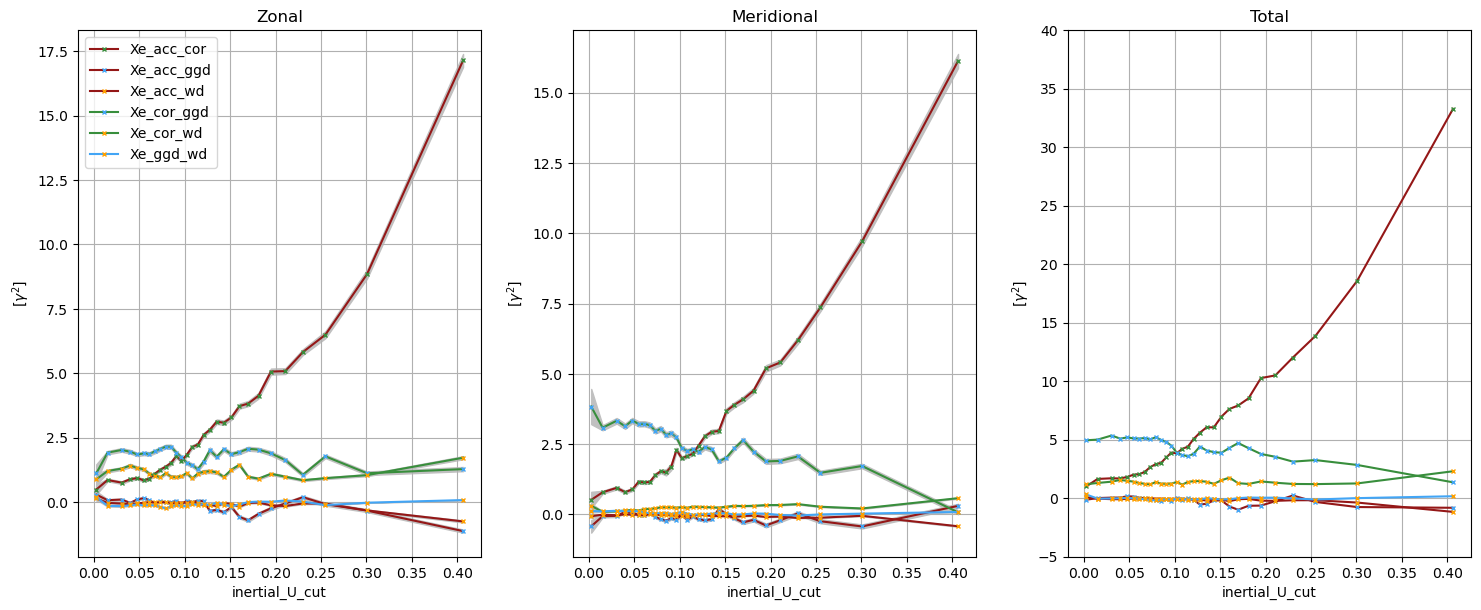

In [81]:
def plot_error(df, v, ax):
    ax.fill_between(df[key_bins+'_cut'], df[v] - df["ber__" + v], df[v] + df["ber__" + v], color="silver")

#plot pair's contributions
Xn = [k for k in ds.keys() if ('Xn' in k)&('ber__' not in k)]
Xe = [k for k in ds.keys() if ('Xe' in k)&('ber__' not in k)]
xstyle = {l.replace('Xn_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in Xn}

fig, axs = plt.subplots(1, 3, figsize=(15,6))
axs =axs.flatten()
for xn in Xn:
    ds[xn].plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
    plot_error(ds, xn, axs[1])
for xe in Xe:
    ds[xe].plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
    plot_error(ds, xe, axs[0])
i=0
for xn in Xn:
    (ds[xn] +ds[Xe[i]]).plot( ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
    i+=1
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
axs[0].legend()

axs[0].set_title('Zonal')
axs[1].set_title('Meridional')
axs[2].set_title('Total')

axs[2].set_ylim(-5, 40)
